# Base 1 — Regresión: Biometría de E-Sports y Tiempo de Reacción

**Inteligencia Computacional II — versión experimental con Cross-Validation**

**Objetivo:** comparar de manera experimental tres algoritmos de regresión —Árbol de Decisión, Random Forest y KNN— para predecir `Reaction_Time_ms`, justificando la selección de hiperparámetros mediante **Cross-Validation (CV)** y reservando el conjunto **TEST exclusivamente para la evaluación final**.

Esta versión incorpora:

- Hold-Out 70/30 antes de cualquier transformación.
- Cross-Validation dentro de TRAIN para seleccionar hiperparámetros.
- Evaluación CV de cada atributo como posible **nodo raíz** mediante árboles tipo *stump* (`max_depth=1`).
- Registro de la raíz realmente seleccionada en cada fold.
- Poda/regularización del Árbol mediante `max_depth`, `min_samples_leaf` y **Cost-Complexity Pruning (`ccp_alpha`)**.
- Comparación Árbol y Random Forest **antes vs. después de poda/regularización**.
- Selección de `K` y `weights` de KNN mediante CV.
- Comparación final homogénea con MAE, RMSE y R².
- Figuras listas para reutilizar en el informe.

> **Nota conceptual sobre KNN:** KNN Regressor no crea clústeres. La visualización final muestra un **vecindario KNN** (observación consultada + sus K vecinos reales), proyectado a 2 dimensiones únicamente para facilitar la interpretación visual.

## 1. Análisis exploratorio de datos (EDA)

In [1]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
CV_FOLDS = 5

# Muestras de TRAIN usadas SOLO para selección de hiperparámetros costosos.
# TEST nunca participa en esta etapa.
TREE_TUNING_SAMPLE = 60_000
RF_TUNING_SAMPLE = 8_000
KNN_TUNING_SAMPLE = 8_000
MODEL_COMPARISON_CV_SAMPLE = 8_000

RESULTS_DIR = Path('resultados_regresion')
RESULTS_DIR.mkdir(exist_ok=True)

# Ruta robusta para ejecutar el notebook tanto desde /mnt/data como desde su carpeta original.
candidates = [
    Path('esports_biometrics.csv'),
    Path('data/esports_biometrics.csv'),
    Path('/mnt/data/esports_biometrics.csv'),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('No se encontró esports_biometrics.csv en las rutas esperadas.')


def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}



def fit_and_test(name, model, Xtr, ytr, Xte, yte):
    """Ajusta sobre TRAIN y evalúa una sola vez sobre TEST."""
    t0 = time.time()
    model.fit(Xtr, ytr)
    fit_s = time.time() - t0
    t0 = time.time()
    pred = model.predict(Xte)
    pred_s = time.time() - t0
    m = regression_metrics(yte, pred)
    return model, pred, {
        'Modelo': name, 'fit_s': fit_s, 'predict_s': pred_s,
        **m,
    }

def tuning_sample(X, y, n, random_state=RANDOM_STATE):
    n = min(n, len(X))
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X), size=n, replace=False)
    return X.iloc[idx].copy(), y.iloc[idx].copy()


def one_se_largest_alpha(cv_table):
    """Regla 1-SE: entre modelos estadísticamente comparables al mejor,
    elegir el de mayor ccp_alpha (más simple/podado)."""
    t = cv_table.copy()
    t['RMSE_mean'] = -t['mean_test_RMSE']
    t['RMSE_std'] = t['std_test_RMSE']
    best_idx = t['RMSE_mean'].idxmin()
    best_mean = t.loc[best_idx, 'RMSE_mean']
    best_se = t.loc[best_idx, 'RMSE_std'] / np.sqrt(CV_FOLDS)
    threshold = best_mean + best_se
    eligible = t[t['RMSE_mean'] <= threshold].copy()
    chosen = eligible.sort_values('param_model__ccp_alpha').iloc[-1]
    return float(chosen['param_model__ccp_alpha']), threshold, chosen


df = pd.read_csv(DATA_PATH)
print('Ruta:', DATA_PATH)
print('Dimensión:', df.shape)
display(df.head())
print('\nTipos de datos:')
print(df.dtypes)
print('\nNulos:')
print(df.isna().sum())

Ruta: data\esports_biometrics.csv
Dimensión: (250000, 13)


,Player_ID,Age,Game_Genre,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,Blue_Light_Filter,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms,Match_Outcome
0,PL_000001,24,FPS,1.41,8.88,0,43.4,Yes,107,78,95.02,268.96,Loss
1,PL_000002,22,FPS,4.43,7.45,2,88.0,Yes,110,102,82.92,281.90,Win
2,PL_000003,25,Battle Royale,3.75,8.10,1,24.8,Yes,152,96,89.13,288.57,Win
3,PL_000004,29,FPS,1.76,6.69,0,80.2,No,151,65,80.41,279.76,Win
4,PL_000005,22,FPS,5.79,8.17,1,34.4,No,148,95,95.71,229.62,Loss



Tipos de datos:
Player_ID                str
Age                    int64
Game_Genre               str
PlayTime_Hours       float64
Sleep_Hours          float64
Energy_Drinks          int64
Screen_Brightness    float64
Blue_Light_Filter        str
APM                    int64
Heart_Rate_BPM         int64
HRV_Score            float64
Reaction_Time_ms     float64
Match_Outcome            str
dtype: object

Nulos:
Player_ID                0
Age                      0
Game_Genre               0
PlayTime_Hours           0
Sleep_Hours              0
Energy_Drinks            0
Screen_Brightness    12548
Blue_Light_Filter        0
APM                      0
Heart_Rate_BPM           0
HRV_Score             4934
Reaction_Time_ms         0
Match_Outcome            0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Player_ID,250000,250000,PL_000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,250000.0,NaN,NaN,NaN,22.588136,3.829706,16.0,20.0,23.0,25.0,40.0
Game_Genre,250000,4,MOBA,99887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PlayTime_Hours,250000.0,NaN,NaN,NaN,2.527753,2.358799,0.5,0.72,1.73,3.47,12.0
Sleep_Hours,250000.0,NaN,NaN,NaN,6.5009,1.495851,2.0,5.49,6.5,7.51,11.0
Energy_Drinks,250000.0,NaN,NaN,NaN,0.91772,1.045559,0.0,0.0,1.0,1.0,4.0
Screen_Brightness,237452.0,NaN,NaN,NaN,54.918735,25.965989,10.0,32.5,54.9,77.4,100.0
Blue_Light_Filter,250000,2,No,162320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APM,250000.0,NaN,NaN,NaN,204.076168,77.004233,30.0,143.0,192.0,263.0,563.0
Heart_Rate_BPM,250000.0,NaN,NaN,NaN,84.062784,9.670229,60.0,77.0,84.0,90.0,129.0


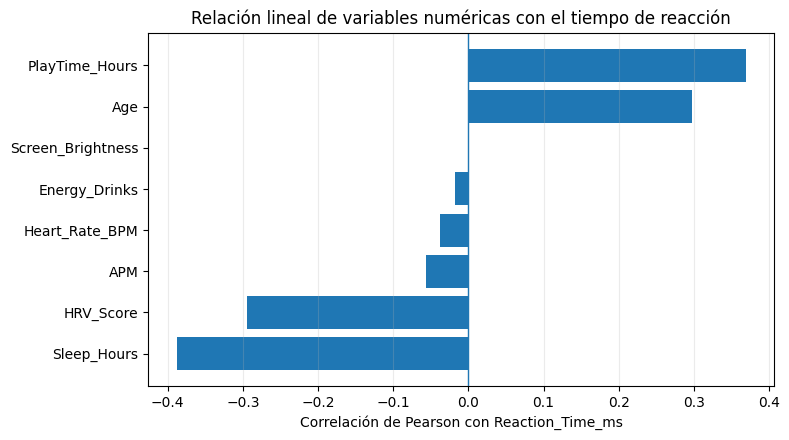


Promedio de Reaction_Time_ms por Match_Outcome:


,mean,std,count
Match_Outcome,,,
Loss,263.942624,19.149059,129844
Win,261.774430,18.976287,120156


In [2]:
display(df.describe(include='all').T)

num_cols_all = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols_all].corr(numeric_only=True)['Reaction_Time_ms'].drop('Reaction_Time_ms').sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(corr.index, corr.values)
ax.axvline(0, linewidth=1)
ax.set_xlabel('Correlación de Pearson con Reaction_Time_ms')
ax.set_title('Relación lineal de variables numéricas con el tiempo de reacción')
ax.grid(axis='x', alpha=.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_01_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPromedio de Reaction_Time_ms por Match_Outcome:')
display(df.groupby('Match_Outcome')['Reaction_Time_ms'].agg(['mean','std','count']))

**Criterio de selección de variables.** Se elimina `Player_ID` porque es un identificador. También se excluye `Match_Outcome` porque, para un escenario predictivo previo/durante la partida, corresponde a información disponible después del resultado y puede introducir *leakage* temporal/causal. No se afirma que su diferencia de medias demuestre por sí sola ausencia de señal.

Las correlaciones del EDA son descriptivas; **no constituyen un límite teórico del R²**. El desempeño final dependerá de relaciones no lineales, interacciones, variables disponibles y capacidad de generalización de cada modelo.

## 2. Hold-Out 70/30 y preprocesamiento reproducible dentro de Cross-Validation

In [3]:
target = 'Reaction_Time_ms'
drop_cols = ['Player_ID', 'Match_Outcome']

X = df.drop(columns=drop_cols + [target]).copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

# Reset para que los índices internos sean consistentes al visualizar vecinos KNN.
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(exclude='number').columns.tolist()
other_numeric = [c for c in numeric_cols if c not in ['Screen_Brightness', 'HRV_Score']]

print(f'TRAIN: {len(X_train):,} ({len(X_train)/len(X):.0%})')
print(f'TEST : {len(X_test):,} ({len(X_test)/len(X):.0%})')
print('Numéricas:', numeric_cols)
print('Categóricas:', categorical_cols)

TRAIN: 175,000 (70%)
TEST : 75,000 (30%)
Numéricas: ['Age', 'PlayTime_Hours', 'Sleep_Hours', 'Energy_Drinks', 'Screen_Brightness', 'APM', 'Heart_Rate_BPM', 'HRV_Score']
Categóricas: ['Game_Genre', 'Blue_Light_Filter']


In [5]:
def make_tree_preprocessor():
    """Árbol/RF: imputación + OHE. No necesitan escalado."""
    return ColumnTransformer(
        transformers=[
            ('screen', SimpleImputer(strategy='mean'), ['Screen_Brightness']),
            ('hrv', SimpleImputer(strategy='median'), ['HRV_Score']),
            ('num', 'passthrough', other_numeric),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ],
        verbose_feature_names_out=False,
    )


def make_knn_preprocessor():
    """KNN: escalar variables numéricas; OHE categóricas sin estandarizar dummies."""
    return ColumnTransformer(
        transformers=[
            ('screen', Pipeline([
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler()),
            ]), ['Screen_Brightness']),
            ('hrv', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), ['HRV_Score']),
            ('num', StandardScaler(), other_numeric),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), categorical_cols),
        ],
        verbose_feature_names_out=False,
    )

cv5 = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2',
}

print('Cross-Validation:', CV_FOLDS, 'folds sobre TRAIN.')
print('Cada pipeline ajusta imputación/codificación/escalado dentro de cada fold para evitar leakage interno.')

Cross-Validation: 5 folds sobre TRAIN.
Cada pipeline ajusta imputación/codificación/escalado dentro de cada fold para evitar leakage interno.


## 3. Árbol de Decisión Regressor

### 3.1 Cross-Validation de cada atributo como candidato a nodo raíz

Para responder de forma explícita **qué tan bueno sería cada atributo si tuviera que actuar como raíz**, se entrena un árbol de profundidad 1 (*decision stump*) usando **un solo atributo a la vez**. Al existir un único atributo, cualquier split del árbol debe provenir de ese atributo. Se reportan RMSE y R² promedio de 5 folds.

Esta prueba no reemplaza al algoritmo CART completo; sirve como experimento interpretativo para medir la capacidad individual de cada atributo en la primera partición.

,Atributo,RMSE_CV_mean,RMSE_CV_std,MAE_CV_mean,R2_CV_mean,R2_CV_std,Ranking_RMSE
0,Sleep_Hours,18.1780,0.0418,14.4809,0.0970,0.0025,1
1,PlayTime_Hours,18.2157,0.0514,14.5211,0.0932,0.0032,2
2,Age,18.5596,0.0371,14.7865,0.0587,0.0020,3
3,HRV_Score,18.5954,0.0214,14.8290,0.0550,0.0028,4
4,APM,19.0811,0.0303,15.2027,0.0050,0.0009,5
5,Energy_Drinks,19.1061,0.0315,15.2207,0.0024,0.0005,6
6,Heart_Rate_BPM,19.1198,0.0275,15.2323,0.0010,0.0004,7
7,Blue_Light_Filter,19.1297,0.0274,15.2391,-0.0000,0.0001,8
8,Game_Genre,19.1297,0.0274,15.2392,-0.0001,0.0001,9
9,Screen_Brightness,19.1300,0.0268,15.2394,-0.0001,0.0001,10


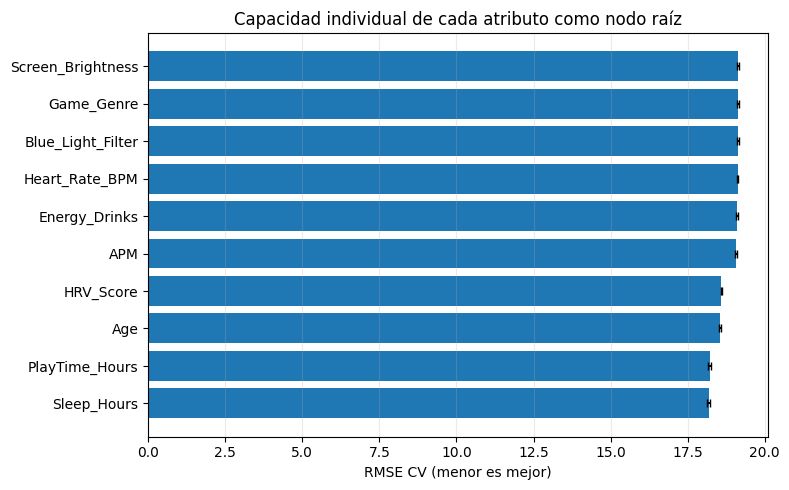

In [6]:
root_attribute_rows = []

for col in X_train.columns:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        if col == 'Screen_Brightness':
            prep = SimpleImputer(strategy='mean')
        elif col == 'HRV_Score':
            prep = SimpleImputer(strategy='median')
        else:
            prep = 'passthrough'
    else:
        prep = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    pipe = Pipeline([
        ('prep', ColumnTransformer([('feature', prep, [col])], verbose_feature_names_out=False)),
        ('model', DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE)),
    ])

    scores = cross_validate(
        pipe, X_train[[col]], y_train,
        cv=cv5, scoring=scoring, n_jobs=1
    )

    root_attribute_rows.append({
        'Atributo': col,
        'RMSE_CV_mean': -scores['test_RMSE'].mean(),
        'RMSE_CV_std': scores['test_RMSE'].std(),
        'MAE_CV_mean': -scores['test_MAE'].mean(),
        'R2_CV_mean': scores['test_R2'].mean(),
        'R2_CV_std': scores['test_R2'].std(),
    })

root_attribute_cv = pd.DataFrame(root_attribute_rows).sort_values('RMSE_CV_mean').reset_index(drop=True)
root_attribute_cv['Ranking_RMSE'] = np.arange(1, len(root_attribute_cv)+1)
display(root_attribute_cv.round(4))
root_attribute_cv.to_csv(RESULTS_DIR / 'tabla_01_cv_atributos_raiz.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = root_attribute_cv.sort_values('RMSE_CV_mean', ascending=True)
ax.barh(plot_df['Atributo'], plot_df['RMSE_CV_mean'], xerr=plot_df['RMSE_CV_std'], capsize=3)
ax.set_xlabel('RMSE CV (menor es mejor)')
ax.set_title('Capacidad individual de cada atributo como nodo raíz')
ax.grid(axis='x', alpha=.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_02_cv_atributos_raiz.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 ¿Qué raíz selecciona realmente CART en cada fold?

Ahora se entregan **todos los atributos simultáneamente**. En cada fold se ajusta un árbol de profundidad 1 y se registra la variable y el umbral elegidos por CART. La raíz se selecciona por la reducción del error cuadrático, no por `feature_importances_`.

Así se puede mostrar tanto la **estabilidad de la elección de raíz** como el resultado de validación de cada fold.

In [7]:
root_fold_rows = []

for fold, (idx_tr, idx_val) in enumerate(cv5.split(X_train), start=1):
    pre = make_tree_preprocessor()
    Xtr_fold = pre.fit_transform(X_train.iloc[idx_tr])
    Xval_fold = pre.transform(X_train.iloc[idx_val])
    names = pre.get_feature_names_out()

    stump = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE)
    stump.fit(Xtr_fold, y_train.iloc[idx_tr])

    root_idx = stump.tree_.feature[0]
    root_feature = names[root_idx]
    threshold = stump.tree_.threshold[0]

    pred = stump.predict(Xval_fold)
    m = regression_metrics(y_train.iloc[idx_val], pred)

    # Agrupar dummies por el atributo original para lectura del informe.
    original_feature = root_feature
    for cat_col in categorical_cols:
        if root_feature.startswith(cat_col + '_'):
            original_feature = cat_col

    root_fold_rows.append({
        'Fold': fold,
        'Raiz_transformada': root_feature,
        'Atributo_original': original_feature,
        'Umbral': threshold,
        'RMSE_validacion': m['RMSE'],
        'R2_validacion': m['R2'],
    })

root_fold_df = pd.DataFrame(root_fold_rows)
display(root_fold_df.round(4))
print('\nFrecuencia de selección como raíz:')
display(root_fold_df['Atributo_original'].value_counts().rename_axis('Atributo').reset_index(name='Folds_como_raiz'))
root_fold_df.to_csv(RESULTS_DIR / 'tabla_02_raiz_seleccionada_por_fold.csv', index=False)

,Fold,Raiz_transformada,Atributo_original,Umbral,RMSE_validacion,R2_validacion
0,1,Sleep_Hours,Sleep_Hours,6.525,18.2115,0.0958
1,2,Sleep_Hours,Sleep_Hours,6.415,18.2250,0.0955
2,3,Sleep_Hours,Sleep_Hours,6.395,18.1955,0.0938
3,4,Sleep_Hours,Sleep_Hours,6.415,18.1407,0.1007
4,5,Sleep_Hours,Sleep_Hours,6.525,18.1173,0.0990



Frecuencia de selección como raíz:


,Atributo,Folds_como_raiz
0,Sleep_Hours,5


### 3.3 Pre-poda mediante CV: `max_depth` + `min_samples_leaf`

La selección ya no utiliza TEST. Se hace un Grid Search con Cross-Validation sobre una muestra reproducible de TRAIN para controlar el costo computacional.

- `max_depth`: limita la profundidad máxima.
- `min_samples_leaf`: evita hojas demasiado específicas.

Ambos son mecanismos de **pre-poda/regularización estructural**.

In [8]:
X_tree_cv, y_tree_cv = tuning_sample(X_train, y_train, TREE_TUNING_SAMPLE)

base_tree_pipe = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE)),
])

tree_param_grid = {
    'model__max_depth': [4, 6, 8, 10, 12],
    'model__min_samples_leaf': [1, 20, 50, 100, 200],
}

tree_grid = GridSearchCV(
    base_tree_pipe,
    param_grid=tree_param_grid,
    scoring=scoring,
    refit='RMSE',
    cv=cv5,
    n_jobs=-1,
    return_train_score=True,
)

t0 = time.time()
tree_grid.fit(X_tree_cv, y_tree_cv)
print(f'Tiempo GridSearch árbol: {time.time()-t0:.2f} s')
print('Mejores parámetros de pre-poda:', tree_grid.best_params_)
print('RMSE CV:', -tree_grid.best_score_)

tree_grid_df = pd.DataFrame(tree_grid.cv_results_)
tree_grid_report = tree_grid_df[[
    'param_model__max_depth', 'param_model__min_samples_leaf',
    'mean_test_RMSE', 'std_test_RMSE', 'mean_test_MAE', 'mean_test_R2',
    'mean_train_RMSE', 'mean_train_R2', 'rank_test_RMSE'
]].copy()
tree_grid_report['RMSE_CV'] = -tree_grid_report['mean_test_RMSE']
tree_grid_report['MAE_CV'] = -tree_grid_report['mean_test_MAE']
tree_grid_report['RMSE_train_CV'] = -tree_grid_report['mean_train_RMSE']
tree_grid_report = tree_grid_report.sort_values('rank_test_RMSE')
display(tree_grid_report.head(12).round(4))
tree_grid_report.to_csv(RESULTS_DIR / 'tabla_03_tree_prepoda_cv.csv', index=False)

best_depth = int(tree_grid.best_params_['model__max_depth'])
best_leaf = int(tree_grid.best_params_['model__min_samples_leaf'])

Tiempo GridSearch árbol: 20.02 s
Mejores parámetros de pre-poda: {'model__max_depth': 8, 'model__min_samples_leaf': 100}
RMSE CV: 15.417472132941327


,param_model__max_depth,param_model__min_samples_leaf,mean_test_RMSE,std_test_RMSE,mean_test_MAE,mean_test_R2,mean_train_RMSE,mean_train_R2,rank_test_RMSE,RMSE_CV,MAE_CV,RMSE_train_CV
13,8,100,-15.4175,0.1016,-12.3046,0.3538,-15.1169,0.3788,1,15.4175,12.3046,15.1169
12,8,50,-15.4228,0.0979,-12.3124,0.3533,-15.0622,0.3833,2,15.4228,12.3124,15.0622
24,12,200,-15.4409,0.0972,-12.3280,0.3518,-15.1484,0.3762,3,15.4409,12.3280,15.1484
19,10,200,-15.4414,0.0986,-12.3283,0.3518,-15.1508,0.3760,4,15.4414,12.3283,15.1508
11,8,20,-15.4437,0.0935,-12.3235,0.3516,-15.0238,0.3864,5,15.4437,12.3235,15.0238
14,8,200,-15.4443,0.0948,-12.3278,0.3515,-15.2087,0.3712,6,15.4443,12.3278,15.2087
18,10,100,-15.4514,0.1115,-12.3346,0.3509,-14.9745,0.3905,7,15.4514,12.3346,14.9745
23,12,100,-15.4780,0.1079,-12.3559,0.3487,-14.9377,0.3934,8,15.4780,12.3559,14.9377
10,8,1,-15.4959,0.0927,-12.3564,0.3472,-14.9916,0.3891,9,15.4959,12.3564,14.9916
17,10,50,-15.5348,0.1108,-12.3958,0.3439,-14.8124,0.4036,10,15.5348,12.3958,14.8124


### 3.4 Post-poda por complejidad de costo (`ccp_alpha`) + regla 1-SE

Después de seleccionar la estructura base, se obtiene la ruta de *Cost-Complexity Pruning*. Se prueban varios `ccp_alpha` mediante 5-fold CV.

En lugar de elegir obligatoriamente el RMSE mínimo absoluto, se aplica la **regla de 1 error estándar (1-SE)**: se acepta un modelo cuyo RMSE sea estadísticamente comparable al mejor y, entre ellos, se elige el de mayor `ccp_alpha`. Esto favorece un árbol más simple sin sacrificar una mejora relevante de generalización.

Candidatos ccp_alpha: [0.         0.05407679 0.08545495 0.12961177 0.23268287 0.39215175
 0.77617956 3.04014648]
Alpha de RMSE mínimo absoluto: 0.0
Umbral 1-SE de RMSE: 15.462896970681483
Alpha elegido por regla 1-SE: 0.05407679


,param_model__ccp_alpha,RMSE_CV,std_test_RMSE,RMSE_train_CV,R2_CV,rank_test_RMSE
0,0.00000,15.41747,0.10157,15.11693,0.35378,1
1,0.05408,15.43369,0.10639,15.16185,0.35243,2
2,0.08545,15.47773,0.10939,15.22489,0.34873,3
3,0.12961,15.53807,0.10073,15.31150,0.34365,4
4,0.23268,15.65125,0.09150,15.45689,0.33405,5
5,0.39215,15.77109,0.09663,15.59877,0.32382,6
6,0.77618,15.98217,0.07130,15.83867,0.30558,7
7,3.04015,16.47476,0.03875,16.41368,0.26207,8


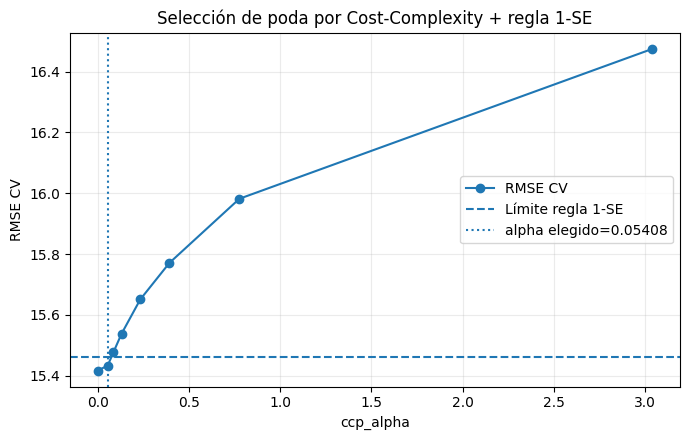

In [9]:
# Obtener candidatos de alpha desde la ruta de poda del árbol pre-podado.
pre_alpha = make_tree_preprocessor()
Xt_alpha = pre_alpha.fit_transform(X_tree_cv)
base_for_path = DecisionTreeRegressor(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    random_state=RANDOM_STATE,
).fit(Xt_alpha, y_tree_cv)

path = base_for_path.cost_complexity_pruning_path(Xt_alpha, y_tree_cv)
raw_alphas = path.ccp_alphas[:-1]
quantiles = [0.00, 0.25, 0.45, 0.60, 0.72, 0.82, 0.90, 0.96]
alpha_candidates = np.unique(np.quantile(raw_alphas, quantiles))
alpha_candidates = np.unique(np.round(alpha_candidates, 8))

print('Candidatos ccp_alpha:', alpha_candidates)

alpha_pipe = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', DecisionTreeRegressor(
        max_depth=best_depth,
        min_samples_leaf=best_leaf,
        random_state=RANDOM_STATE,
    )),
])

alpha_grid = GridSearchCV(
    alpha_pipe,
    param_grid={'model__ccp_alpha': alpha_candidates},
    scoring=scoring,
    refit='RMSE',
    cv=cv5,
    n_jobs=-1,
    return_train_score=True,
)
alpha_grid.fit(X_tree_cv, y_tree_cv)

alpha_cv = pd.DataFrame(alpha_grid.cv_results_)
alpha_cv['RMSE_CV'] = -alpha_cv['mean_test_RMSE']
alpha_cv['RMSE_train_CV'] = -alpha_cv['mean_train_RMSE']
alpha_cv['R2_CV'] = alpha_cv['mean_test_R2']
alpha_cv = alpha_cv.sort_values('param_model__ccp_alpha')

best_alpha_absolute = float(alpha_grid.best_params_['model__ccp_alpha'])
chosen_alpha, threshold_1se, chosen_alpha_row = one_se_largest_alpha(pd.DataFrame(alpha_grid.cv_results_))

print('Alpha de RMSE mínimo absoluto:', best_alpha_absolute)
print('Umbral 1-SE de RMSE:', threshold_1se)
print('Alpha elegido por regla 1-SE:', chosen_alpha)
display(alpha_cv[[
    'param_model__ccp_alpha', 'RMSE_CV', 'std_test_RMSE', 'RMSE_train_CV', 'R2_CV', 'rank_test_RMSE'
]].round(5))
alpha_cv.to_csv(RESULTS_DIR / 'tabla_04_tree_ccp_alpha_cv.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(alpha_cv['param_model__ccp_alpha'], alpha_cv['RMSE_CV'], marker='o', label='RMSE CV')
ax.axhline(threshold_1se, linestyle='--', label='Límite regla 1-SE')
ax.axvline(chosen_alpha, linestyle=':', label=f'alpha elegido={chosen_alpha:.4g}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('RMSE CV')
ax.set_title('Selección de poda por Cost-Complexity + regla 1-SE')
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_03_tree_ccp_alpha_cv.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Árbol antes y después de poda: entrenamiento final y evaluación TEST

In [10]:
tree_unpruned = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', DecisionTreeRegressor(
        max_depth=None, min_samples_leaf=1, ccp_alpha=0.0,
        random_state=RANDOM_STATE,
    )),
])

tree_pruned = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', DecisionTreeRegressor(
        max_depth=best_depth,
        min_samples_leaf=best_leaf,
        ccp_alpha=chosen_alpha,
        random_state=RANDOM_STATE,
    )),
])

tree_unpruned, pred_tree_unpruned, row_tree_unpruned = fit_and_test(
    'Árbol sin poda', tree_unpruned, X_train, y_train, X_test, y_test
)
tree_pruned, pred_tree_pruned, row_tree_pruned = fit_and_test(
    'Árbol podado CV', tree_pruned, X_train, y_train, X_test, y_test
)

for label, pipe in [('Sin poda', tree_unpruned), ('Podado', tree_pruned)]:
    estimator = pipe.named_steps['model']
    print(f"{label}: profundidad={estimator.get_depth()} | hojas={estimator.get_n_leaves()}")

tree_before_after = pd.DataFrame([row_tree_unpruned, row_tree_pruned])
display(tree_before_after.round(4))

Sin poda: profundidad=53 | hojas=174906
Podado: profundidad=8 | hojas=128


,Modelo,fit_s,predict_s,MAE,RMSE,R2
0,Árbol sin poda,1.9439,0.0899,17.4171,21.8409,-0.3186
1,Árbol podado CV,0.6230,0.0403,12.2279,15.3323,0.3502


Nodo raíz del árbol final: Sleep_Hours
Umbral de la raíz: 6.394999980926514


,Variable_transformada,Importancia_MDI
4,Sleep_Hours,0.40534
3,PlayTime_Hours,0.36769
2,Age,0.22697
0,Screen_Brightness,0.00000
1,HRV_Score,0.00000
5,Energy_Drinks,0.00000
6,APM,0.00000
7,Heart_Rate_BPM,0.00000
8,Game_Genre_Battle Royale,0.00000
9,Game_Genre_FPS,0.00000


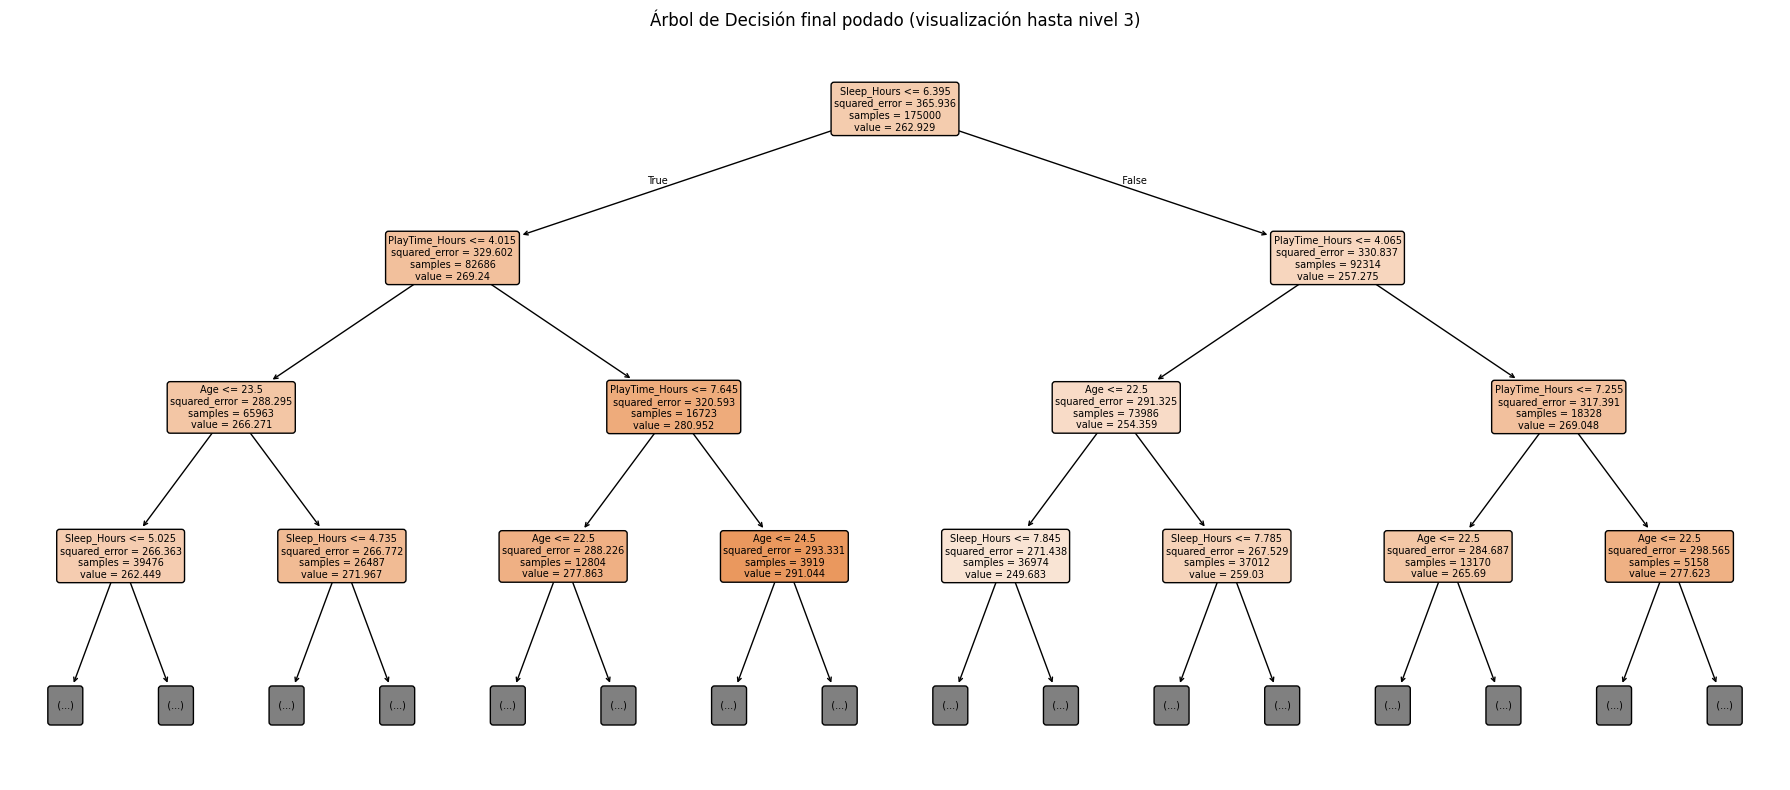

In [11]:
# Nodo raíz REAL e importancias del árbol podado final.
pre_fitted = tree_pruned.named_steps['preprocessor']
final_tree_estimator = tree_pruned.named_steps['model']
feature_names_tree = pre_fitted.get_feature_names_out()

root_index = final_tree_estimator.tree_.feature[0]
root_feature = feature_names_tree[root_index]
root_threshold = final_tree_estimator.tree_.threshold[0]
print('Nodo raíz del árbol final:', root_feature)
print('Umbral de la raíz:', root_threshold)

importance_df = pd.DataFrame({
    'Variable_transformada': feature_names_tree,
    'Importancia_MDI': final_tree_estimator.feature_importances_,
}).sort_values('Importancia_MDI', ascending=False)
display(importance_df.head(15).round(5))

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    final_tree_estimator,
    feature_names=feature_names_tree,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=7,
    ax=ax,
)
ax.set_title('Árbol de Decisión final podado (visualización hasta nivel 3)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_04_arbol_decision_podado.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Random Forest Regressor

Random Forest utiliza **bootstrap** sobre las filas de TRAIN: cada árbol recibe una muestra con reemplazo del mismo tamaño que TRAIN (salvo que se defina `max_samples`). No divide el dataset en bloques disjuntos. Además, `max_features` controla cuántas variables se consideran en cada split.

Para mantener el experimento simple y explicable, la selección CV se hace por etapas sobre una muestra fija de TRAIN. TEST permanece aislado.

In [12]:
X_rf_cv, y_rf_cv = tuning_sample(X_train, y_train, RF_TUNING_SAMPLE)

# Etapa A: estructura/poda de cada árbol del bosque.
rf_struct_pipe = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', RandomForestRegressor(
        n_estimators=25,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_struct_grid = GridSearchCV(
    rf_struct_pipe,
    param_grid={
        'model__max_depth': [8, 12, None],
        'model__min_samples_leaf': [1, 50, 100],
    },
    scoring=scoring,
    refit='RMSE',
    cv=cv5,
    n_jobs=1,  # evita paralelismo anidado excesivo
    return_train_score=True,
)
rf_struct_grid.fit(X_rf_cv, y_rf_cv)
print('Mejor estructura RF:', rf_struct_grid.best_params_)
print('RMSE CV:', -rf_struct_grid.best_score_)

rf_struct_df = pd.DataFrame(rf_struct_grid.cv_results_)
rf_struct_df['RMSE_CV'] = -rf_struct_df['mean_test_RMSE']
rf_struct_df['R2_CV'] = rf_struct_df['mean_test_R2']
rf_struct_df = rf_struct_df.sort_values('rank_test_RMSE')
display(rf_struct_df[[
    'param_model__max_depth', 'param_model__min_samples_leaf',
    'RMSE_CV', 'std_test_RMSE', 'R2_CV', 'rank_test_RMSE'
]].round(4))
rf_struct_df.to_csv(RESULTS_DIR / 'tabla_05_rf_estructura_cv.csv', index=False)

rf_best_depth = rf_struct_grid.best_params_['model__max_depth']
rf_best_leaf = int(rf_struct_grid.best_params_['model__min_samples_leaf'])

Mejor estructura RF: {'model__max_depth': 8, 'model__min_samples_leaf': 50}
RMSE CV: 15.351591832585305


,param_model__max_depth,param_model__min_samples_leaf,RMSE_CV,std_test_RMSE,R2_CV,rank_test_RMSE
1,8,50,15.3516,0.1848,0.3559,1
4,12,50,15.3556,0.1850,0.3556,2
7,None,50,15.3556,0.1850,0.3556,2
0,8,1,15.3745,0.2243,0.3540,4
5,12,100,15.4619,0.1842,0.3466,5
8,None,100,15.4619,0.1842,0.3466,5
2,8,100,15.4619,0.1842,0.3466,7
3,12,1,15.6141,0.2739,0.3338,8
6,None,1,15.8259,0.2666,0.3156,9


In [13]:
# Etapa B: cantidad de árboles y aleatoriedad de variables.
rf_ensemble_pipe = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', RandomForestRegressor(
        max_depth=rf_best_depth,
        min_samples_leaf=rf_best_leaf,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_ensemble_grid = GridSearchCV(
    rf_ensemble_pipe,
    param_grid={
        'model__n_estimators': [25, 50, 75],
        'model__max_features': [0.5, 1.0],
    },
    scoring=scoring,
    refit='RMSE',
    cv=cv5,
    n_jobs=1,
    return_train_score=True,
)
rf_ensemble_grid.fit(X_rf_cv, y_rf_cv)
print('Mejor ensamble RF:', rf_ensemble_grid.best_params_)
print('RMSE CV:', -rf_ensemble_grid.best_score_)

rf_ensemble_df = pd.DataFrame(rf_ensemble_grid.cv_results_)
rf_ensemble_df['RMSE_CV'] = -rf_ensemble_df['mean_test_RMSE']
rf_ensemble_df['R2_CV'] = rf_ensemble_df['mean_test_R2']
rf_ensemble_df = rf_ensemble_df.sort_values('rank_test_RMSE')
display(rf_ensemble_df[[
    'param_model__n_estimators', 'param_model__max_features',
    'RMSE_CV', 'std_test_RMSE', 'R2_CV', 'rank_test_RMSE'
]].round(4))
rf_ensemble_df.to_csv(RESULTS_DIR / 'tabla_06_rf_ensamble_cv.csv', index=False)

rf_best_n = int(rf_ensemble_grid.best_params_['model__n_estimators'])
rf_best_features = rf_ensemble_grid.best_params_['model__max_features']

Mejor ensamble RF: {'model__max_features': 1.0, 'model__n_estimators': 50}
RMSE CV: 15.34329607055004


,param_model__n_estimators,param_model__max_features,RMSE_CV,std_test_RMSE,R2_CV,rank_test_RMSE
4,50,1.0,15.3433,0.1900,0.3566,1
5,75,1.0,15.3484,0.1939,0.3562,2
3,25,1.0,15.3516,0.1848,0.3559,3
2,75,0.5,15.3790,0.2115,0.3537,4
1,50,0.5,15.3795,0.2050,0.3536,5
0,25,0.5,15.3879,0.1848,0.3529,6


### 4.1 `ccp_alpha` en Random Forest y comparación antes/después de poda

In [14]:
# Usar el alpha encontrado en el árbol como referencia de escala, pero volver a validarlo para RF.
if chosen_alpha > 0:
    rf_alpha_candidates = np.unique(np.round([0.0, chosen_alpha/2, chosen_alpha], 8))
else:
    rf_alpha_candidates = np.array([0.0, 0.03, 0.06])

rf_alpha_pipe = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', RandomForestRegressor(
        n_estimators=rf_best_n,
        max_depth=rf_best_depth,
        min_samples_leaf=rf_best_leaf,
        max_features=rf_best_features,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_alpha_grid = GridSearchCV(
    rf_alpha_pipe,
    param_grid={'model__ccp_alpha': rf_alpha_candidates},
    scoring=scoring,
    refit='RMSE',
    cv=cv5,
    n_jobs=1,
    return_train_score=True,
)
rf_alpha_grid.fit(X_rf_cv, y_rf_cv)

rf_alpha_cv_raw = pd.DataFrame(rf_alpha_grid.cv_results_)
rf_alpha_cv_raw['RMSE_CV'] = -rf_alpha_cv_raw['mean_test_RMSE']
rf_alpha_cv_raw['R2_CV'] = rf_alpha_cv_raw['mean_test_R2']

# Regla 1-SE adaptada al RF.
rf_best_idx = rf_alpha_cv_raw['RMSE_CV'].idxmin()
rf_best_mean = rf_alpha_cv_raw.loc[rf_best_idx, 'RMSE_CV']
rf_best_se = rf_alpha_cv_raw.loc[rf_best_idx, 'std_test_RMSE'] / np.sqrt(CV_FOLDS)
rf_threshold = rf_best_mean + rf_best_se
rf_eligible = rf_alpha_cv_raw[rf_alpha_cv_raw['RMSE_CV'] <= rf_threshold]
rf_chosen_alpha = float(rf_eligible.sort_values('param_model__ccp_alpha').iloc[-1]['param_model__ccp_alpha'])

print('Alpha RF de RMSE mínimo:', rf_alpha_grid.best_params_['model__ccp_alpha'])
print('Alpha RF elegido por 1-SE:', rf_chosen_alpha)
display(rf_alpha_cv_raw[[
    'param_model__ccp_alpha','RMSE_CV','std_test_RMSE','R2_CV','rank_test_RMSE'
]].sort_values('param_model__ccp_alpha').round(5))
rf_alpha_cv_raw.to_csv(RESULTS_DIR / 'tabla_07_rf_ccp_alpha_cv.csv', index=False)

Alpha RF de RMSE mínimo: 0.05407679
Alpha RF elegido por 1-SE: 0.05407679


,param_model__ccp_alpha,RMSE_CV,std_test_RMSE,R2_CV,rank_test_RMSE
0,0.00000,15.34330,0.19002,0.35662,2
1,0.02704,15.34333,0.19000,0.35661,3
2,0.05408,15.34319,0.18993,0.35662,1


In [15]:
rf_unpruned = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', RandomForestRegressor(
        n_estimators=rf_best_n,
        max_depth=None,
        min_samples_leaf=1,
        ccp_alpha=0.0,
        max_features=rf_best_features,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_pruned = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', RandomForestRegressor(
        n_estimators=rf_best_n,
        max_depth=rf_best_depth,
        min_samples_leaf=rf_best_leaf,
        ccp_alpha=rf_chosen_alpha,
        max_features=rf_best_features,
        bootstrap=True,
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_unpruned, pred_rf_unpruned, row_rf_unpruned = fit_and_test(
    'Random Forest sin poda', rf_unpruned, X_train, y_train, X_test, y_test
)
rf_pruned, pred_rf_pruned, row_rf_pruned = fit_and_test(
    'Random Forest podado CV', rf_pruned, X_train, y_train, X_test, y_test
)

print('OOB R² del RF podado:', rf_pruned.named_steps['model'].oob_score_)
rf_before_after = pd.DataFrame([row_rf_unpruned, row_rf_pruned])
display(rf_before_after.round(4))

pruning_comparison = pd.concat([tree_before_after, rf_before_after], ignore_index=True)
display(pruning_comparison.round(4))
pruning_comparison.to_csv(RESULTS_DIR / 'tabla_08_antes_despues_poda.csv', index=False)

OOB R² del RF podado: 0.37057559360069936


,Modelo,fit_s,predict_s,MAE,RMSE,R2
0,Random Forest sin poda,10.5504,2.2434,12.2846,15.4045,0.3441
1,Random Forest podado CV,6.2436,0.0883,12.0862,15.1495,0.3656


,Modelo,fit_s,predict_s,MAE,RMSE,R2
0,Árbol sin poda,1.9439,0.0899,17.4171,21.8409,-0.3186
1,Árbol podado CV,0.6230,0.0403,12.2279,15.3323,0.3502
2,Random Forest sin poda,10.5504,2.2434,12.2846,15.4045,0.3441
3,Random Forest podado CV,6.2436,0.0883,12.0862,15.1495,0.3656


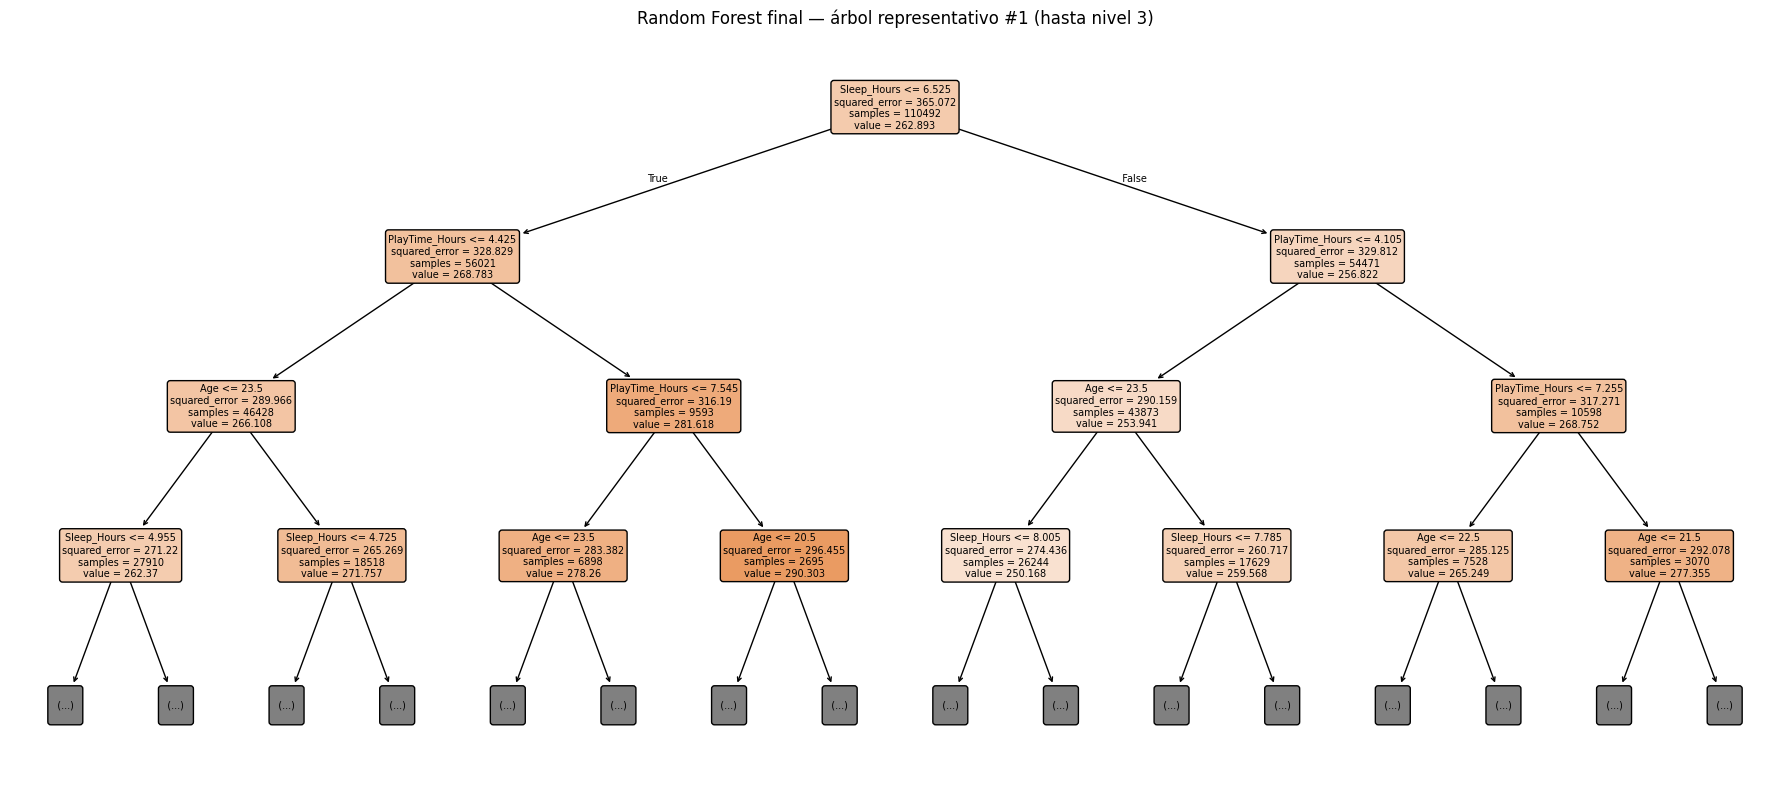

,Variable_transformada,Importancia_MDI
4,Sleep_Hours,0.40438
3,PlayTime_Hours,0.36739
2,Age,0.22778
5,Energy_Drinks,0.00037
1,HRV_Score,0.00004
0,Screen_Brightness,0.00001
9,Game_Genre_FPS,0.00001
7,Heart_Rate_BPM,0.00001
6,APM,0.00000
8,Game_Genre_Battle Royale,0.00000


In [16]:
# Imagen de un árbol representativo del Random Forest final.
rf_pre = rf_pruned.named_steps['preprocessor']
rf_est = rf_pruned.named_steps['model']
rf_feature_names = rf_pre.get_feature_names_out()
representative_tree = rf_est.estimators_[0]

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    representative_tree,
    feature_names=rf_feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=7,
    ax=ax,
)
ax.set_title('Random Forest final — árbol representativo #1 (hasta nivel 3)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_05_random_forest_arbol_representativo.png', dpi=180, bbox_inches='tight')
plt.show()

rf_importance = pd.DataFrame({
    'Variable_transformada': rf_feature_names,
    'Importancia_MDI': rf_est.feature_importances_,
}).sort_values('Importancia_MDI', ascending=False)
display(rf_importance.head(15).round(5))

## 5. KNN Regressor

### 5.1 Selección conjunta de `K` y `weights` mediante Cross-Validation

El K ya no se elige mirando una muestra de TEST. Se evalúan simultáneamente distintos `n_neighbors` y los dos esquemas de peso (`uniform` y `distance`) mediante 5-fold CV sobre una muestra reproducible de TRAIN.

El preprocesador de KNN escala **solo las variables numéricas** y deja las dummies categóricas en 0/1; además elimina una dummy redundante en variables binarias (`drop='if_binary'`).

In [17]:
X_knn_cv, y_knn_cv = tuning_sample(X_train, y_train, KNN_TUNING_SAMPLE)

knn_pipe = Pipeline([
    ('preprocessor', make_knn_preprocessor()),
    ('model', KNeighborsRegressor(n_jobs=-1)),
])

knn_grid = GridSearchCV(
    knn_pipe,
    param_grid={
        'model__n_neighbors': [5, 10, 20, 30, 50, 70, 100, 150],
        'model__weights': ['uniform', 'distance'],
    },
    scoring=scoring,
    refit='RMSE',
    cv=cv5,
    n_jobs=1,
    return_train_score=False,
)

t0 = time.time()
knn_grid.fit(X_knn_cv, y_knn_cv)
print(f'Tiempo GridSearch KNN: {time.time()-t0:.2f} s')
print('Mejores parámetros KNN:', knn_grid.best_params_)
print('RMSE CV:', -knn_grid.best_score_)

knn_cv = pd.DataFrame(knn_grid.cv_results_)
knn_cv['RMSE_CV'] = -knn_cv['mean_test_RMSE']
knn_cv['MAE_CV'] = -knn_cv['mean_test_MAE']
knn_cv['R2_CV'] = knn_cv['mean_test_R2']
knn_cv = knn_cv.sort_values('rank_test_RMSE')
display(knn_cv[[
    'param_model__n_neighbors','param_model__weights',
    'RMSE_CV','std_test_RMSE','MAE_CV','R2_CV','rank_test_RMSE'
]].round(4))
knn_cv.to_csv(RESULTS_DIR / 'tabla_09_knn_cv.csv', index=False)

best_k = int(knn_grid.best_params_['model__n_neighbors'])
best_weights = knn_grid.best_params_['model__weights']

Tiempo GridSearch KNN: 12.00 s
Mejores parámetros KNN: {'model__n_neighbors': 50, 'model__weights': 'distance'}
RMSE CV: 15.703789317216692


,param_model__n_neighbors,param_model__weights,RMSE_CV,std_test_RMSE,MAE_CV,R2_CV,rank_test_RMSE
9,50,distance,15.7038,0.2820,12.5186,0.3262,1
11,70,distance,15.7171,0.2772,12.5335,0.3251,2
8,50,uniform,15.7259,0.2791,12.5338,0.3243,3
7,30,distance,15.7309,0.2716,12.5437,0.3239,4
10,70,uniform,15.7425,0.2741,12.5533,0.3229,5
6,30,uniform,15.7502,0.2650,12.5540,0.3222,6
13,100,distance,15.7525,0.2881,12.5625,0.3221,7
5,20,distance,15.7770,0.3112,12.5727,0.3200,8
12,100,uniform,15.7813,0.2878,12.5855,0.3196,9
4,20,uniform,15.7851,0.3088,12.5704,0.3192,10


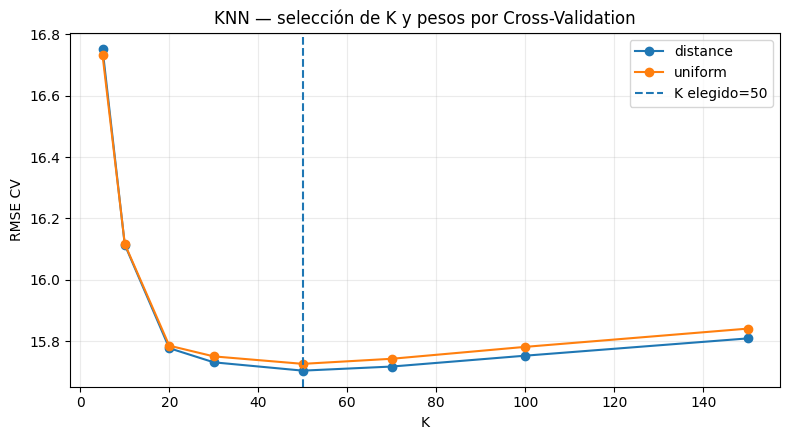

In [18]:
# Curva K por tipo de pesos.
fig, ax = plt.subplots(figsize=(8, 4.5))
for w, group in knn_cv.groupby('param_model__weights'):
    g = group.sort_values('param_model__n_neighbors')
    ax.plot(g['param_model__n_neighbors'], g['RMSE_CV'], marker='o', label=str(w))
ax.axvline(best_k, linestyle='--', label=f'K elegido={best_k}')
ax.set_xlabel('K')
ax.set_ylabel('RMSE CV')
ax.set_title('KNN — selección de K y pesos por Cross-Validation')
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_06_knn_cv_k.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 KNN final sobre TEST y visualización de vecindario

In [19]:
knn_final = Pipeline([
    ('preprocessor', make_knn_preprocessor()),
    ('model', KNeighborsRegressor(
        n_neighbors=best_k,
        weights=best_weights,
        n_jobs=-1,
    )),
])

knn_final, pred_knn, row_knn = fit_and_test(
    f'KNN K={best_k} ({best_weights})',
    knn_final, X_train, y_train, X_test, y_test
)
display(pd.DataFrame([row_knn]).round(4))

,Modelo,fit_s,predict_s,MAE,RMSE,R2
0,KNN K=50 (distance),0.7012,23.857,12.1874,15.2923,0.3536


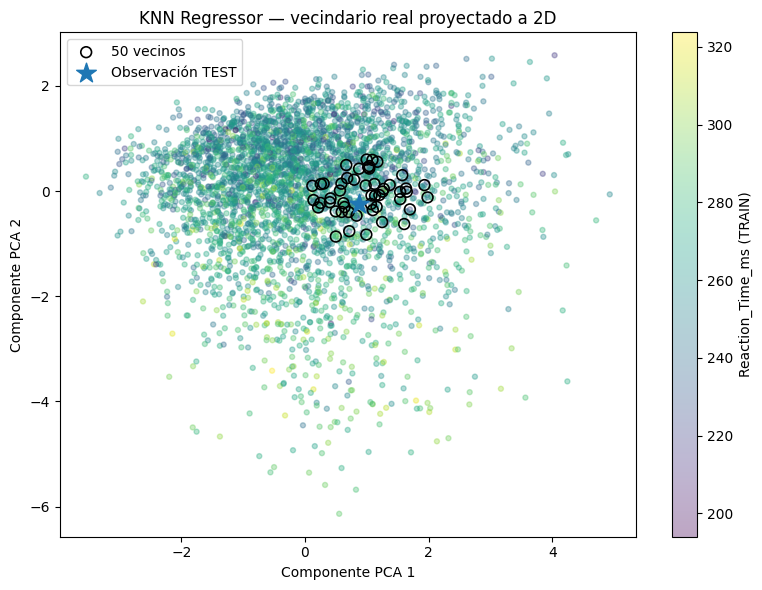

Reaction_Time real de la consulta: 262.46
Predicción KNN: 254.92321539946903
Distancia media a los vecinos: 1.1686147478796944


In [20]:
# Visualización: NO son clústeres. Se muestran los K vecinos reales de una observación de TEST.
knn_pre = knn_final.named_steps['preprocessor']
knn_est = knn_final.named_steps['model']

Xtr_knn = knn_pre.transform(X_train)
Xte_knn = knn_pre.transform(X_test)

# Elegir una observación de test cercana a la mediana del target para evitar un caso extremo.
query_pos = int((y_test - y_test.median()).abs().idxmin())
query_vec = Xte_knn[query_pos:query_pos+1]
distances, neighbor_idx = knn_est.kneighbors(query_vec, n_neighbors=best_k)
neighbor_idx = neighbor_idx[0]

rng = np.random.default_rng(RANDOM_STATE)
background_idx = rng.choice(len(X_train), size=min(3500, len(X_train)), replace=False)
combined_idx = np.unique(np.concatenate([background_idx, neighbor_idx]))

X_vis = Xtr_knn[combined_idx]
y_vis = y_train.iloc[combined_idx].to_numpy()

# PCA solo para visualizar; los vecinos se determinaron ANTES, en el espacio KNN real.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca.fit(np.vstack([X_vis, query_vec]))
proj = pca.transform(X_vis)
query_proj = pca.transform(query_vec)[0]

pos_map = {idx: pos for pos, idx in enumerate(combined_idx)}
neighbor_positions = [pos_map[i] for i in neighbor_idx]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(proj[:,0], proj[:,1], c=y_vis, s=13, alpha=.35)
ax.scatter(proj[neighbor_positions,0], proj[neighbor_positions,1], s=60, facecolors='none', edgecolors='black', linewidths=1.2, label=f'{best_k} vecinos')
ax.scatter(query_proj[0], query_proj[1], marker='*', s=220, label='Observación TEST')
ax.set_xlabel('Componente PCA 1')
ax.set_ylabel('Componente PCA 2')
ax.set_title('KNN Regressor — vecindario real proyectado a 2D')
ax.legend()
plt.colorbar(sc, ax=ax, label='Reaction_Time_ms (TRAIN)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_07_knn_vecindario.png', dpi=180, bbox_inches='tight')
plt.show()

print('Reaction_Time real de la consulta:', y_test.iloc[query_pos])
print('Predicción KNN:', knn_final.predict(X_test.iloc[[query_pos]])[0])
print('Distancia media a los vecinos:', distances.mean())

## 6. Comparación experimental final de modelos

La comparación final utiliza **el mismo conjunto TEST** para todos los modelos, pero solo después de haber fijado sus hiperparámetros con CV. Se incluye un `DummyRegressor` como baseline: predice siempre la media de TRAIN.

Las tablas de CV y TEST cumplen funciones distintas:

- **CV:** selección/justificación de configuración sin tocar TEST.
- **TEST:** estimación final de generalización y comparación entre algoritmos.

,Modelo,fit_s,predict_s,MAE,RMSE,R2,Reduccion_RMSE_vs_baseline_%
0,Random Forest podado CV,6.2436,0.0883,12.0862,15.1495,0.3656,20.3526
1,KNN K=50 (distance),0.7012,23.8570,12.1874,15.2923,0.3536,19.6019
2,Árbol podado CV,0.6230,0.0403,12.2279,15.3323,0.3502,19.3918
3,Baseline (media),0.0951,0.0285,15.1553,19.0207,-0.0000,0.0000


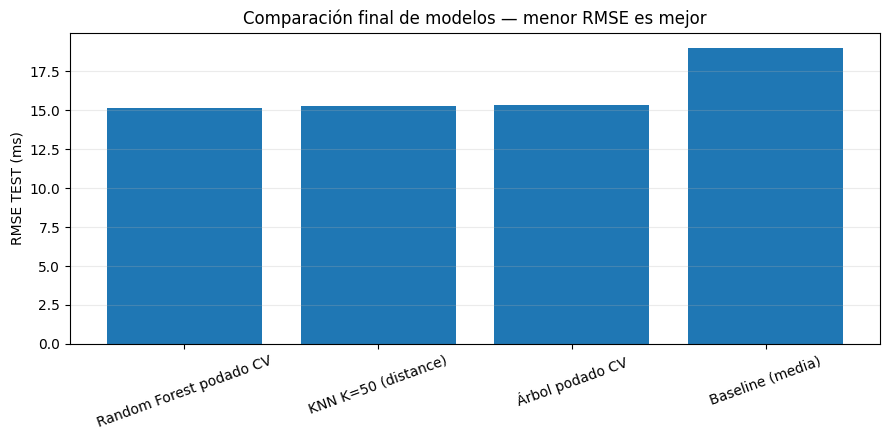

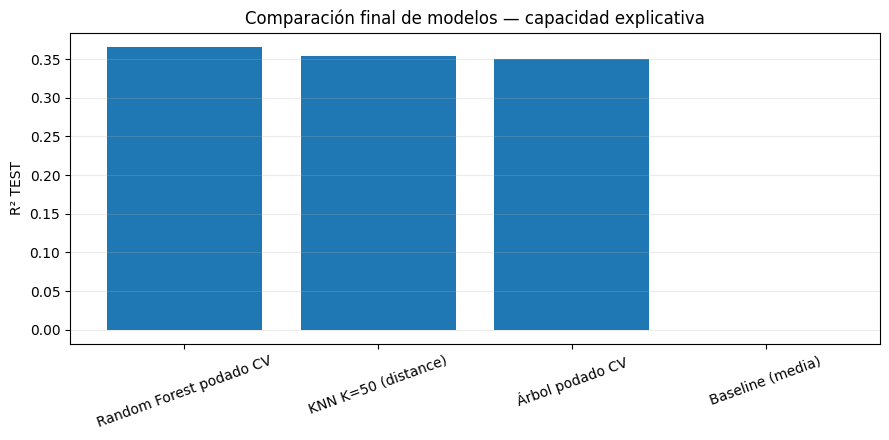

In [21]:
dummy = Pipeline([
    ('preprocessor', make_tree_preprocessor()),
    ('model', DummyRegressor(strategy='mean')),
])
dummy, pred_dummy, row_dummy = fit_and_test(
    'Baseline (media)', dummy, X_train, y_train, X_test, y_test
)

final_rows = [
    row_dummy,
    row_tree_pruned,
    row_rf_pruned,
    row_knn,
]
final_comparison = pd.DataFrame(final_rows).sort_values('RMSE').reset_index(drop=True)
final_comparison['Reduccion_RMSE_vs_baseline_%'] = (
    (row_dummy['RMSE'] - final_comparison['RMSE']) / row_dummy['RMSE'] * 100
)

display(final_comparison.round(4))
final_comparison.to_csv(RESULTS_DIR / 'tabla_10_comparacion_final_test.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(final_comparison['Modelo'], final_comparison['RMSE'])
ax.set_ylabel('RMSE TEST (ms)')
ax.set_title('Comparación final de modelos — menor RMSE es mejor')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_08_comparacion_modelos_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(final_comparison['Modelo'], final_comparison['R2'])
ax.set_ylabel('R² TEST')
ax.set_title('Comparación final de modelos — capacidad explicativa')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_09_comparacion_modelos_r2.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1 Comparación común por Cross-Validation de las configuraciones finales

Además de TEST, se ejecuta una comparación descriptiva sobre **la misma muestra de TRAIN y los mismos 5 folds** para las configuraciones ya fijadas. Esta tabla permite observar la estabilidad (media ± desviación estándar) de cada algoritmo. No se utiliza para volver a cambiar hiperparámetros; la comparación final independiente sigue siendo TEST.

,Modelo,Muestra_CV,Folds,RMSE_CV_mean,RMSE_CV_std,MAE_CV_mean,MAE_CV_std,R2_CV_mean,R2_CV_std,fit_time_mean_s,score_time_mean_s
0,Random Forest podado CV,8000,5,15.3361,0.3344,12.2590,0.3390,0.3650,0.0080,0.1385,0.0339
1,KNN K=50 (distance),8000,5,15.6981,0.2967,12.4916,0.2726,0.3346,0.0065,0.0262,0.1331
2,Árbol podado CV,8000,5,15.8501,0.3087,12.6504,0.3164,0.3216,0.0073,0.0291,0.0081
3,Baseline (media),8000,5,19.2487,0.3250,15.3944,0.2423,-0.0005,0.0005,0.0104,0.0057


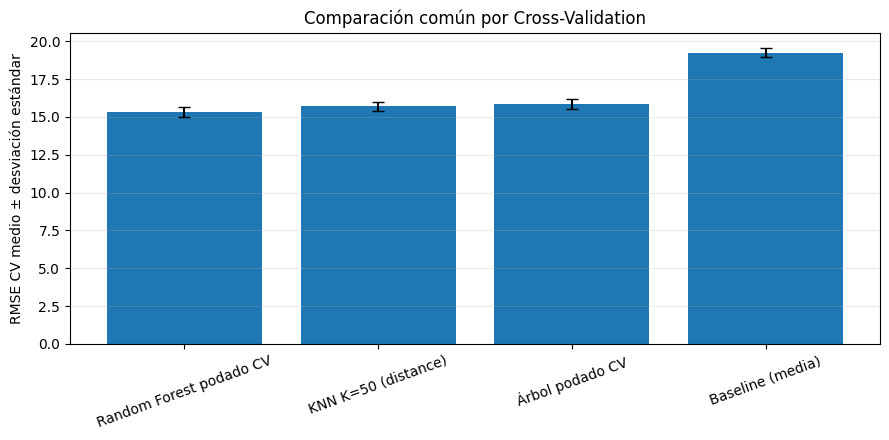

In [22]:
X_common_cv, y_common_cv = tuning_sample(
    X_train, y_train, MODEL_COMPARISON_CV_SAMPLE, random_state=2026
)

common_cv_models = {
    'Baseline (media)': Pipeline([
        ('preprocessor', make_tree_preprocessor()),
        ('model', DummyRegressor(strategy='mean')),
    ]),
    'Árbol podado CV': Pipeline([
        ('preprocessor', make_tree_preprocessor()),
        ('model', DecisionTreeRegressor(
            max_depth=best_depth,
            min_samples_leaf=best_leaf,
            ccp_alpha=chosen_alpha,
            random_state=RANDOM_STATE,
        )),
    ]),
    'Random Forest podado CV': Pipeline([
        ('preprocessor', make_tree_preprocessor()),
        ('model', RandomForestRegressor(
            n_estimators=rf_best_n,
            max_depth=rf_best_depth,
            min_samples_leaf=rf_best_leaf,
            ccp_alpha=rf_chosen_alpha,
            max_features=rf_best_features,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    f'KNN K={best_k} ({best_weights})': Pipeline([
        ('preprocessor', make_knn_preprocessor()),
        ('model', KNeighborsRegressor(
            n_neighbors=best_k,
            weights=best_weights,
            n_jobs=-1,
        )),
    ]),
}

common_cv_rows = []
for name, model in common_cv_models.items():
    scores = cross_validate(
        model, X_common_cv, y_common_cv,
        cv=cv5, scoring=scoring, n_jobs=1,
        return_train_score=False,
    )
    common_cv_rows.append({
        'Modelo': name,
        'Muestra_CV': len(X_common_cv),
        'Folds': CV_FOLDS,
        'RMSE_CV_mean': -scores['test_RMSE'].mean(),
        'RMSE_CV_std': scores['test_RMSE'].std(),
        'MAE_CV_mean': -scores['test_MAE'].mean(),
        'MAE_CV_std': scores['test_MAE'].std(),
        'R2_CV_mean': scores['test_R2'].mean(),
        'R2_CV_std': scores['test_R2'].std(),
        'fit_time_mean_s': scores['fit_time'].mean(),
        'score_time_mean_s': scores['score_time'].mean(),
    })

common_cv_summary = pd.DataFrame(common_cv_rows).sort_values('RMSE_CV_mean').reset_index(drop=True)
display(common_cv_summary.round(4))
common_cv_summary.to_csv(RESULTS_DIR / 'tabla_11_comparacion_cv_comun.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(
    common_cv_summary['Modelo'],
    common_cv_summary['RMSE_CV_mean'],
    yerr=common_cv_summary['RMSE_CV_std'],
    capsize=4,
)
ax.set_ylabel('RMSE CV medio ± desviación estándar')
ax.set_title('Comparación común por Cross-Validation')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_10_comparacion_cv_comun.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Diagnóstico de residuos de los modelos finales

,Modelo,Residual_mean,Residual_std,Residual_MAE
0,Árbol podado,0.0347,15.3322,12.2279
1,Random Forest podado,0.0270,15.1495,12.0862
2,KNN,0.4459,15.2858,12.1874


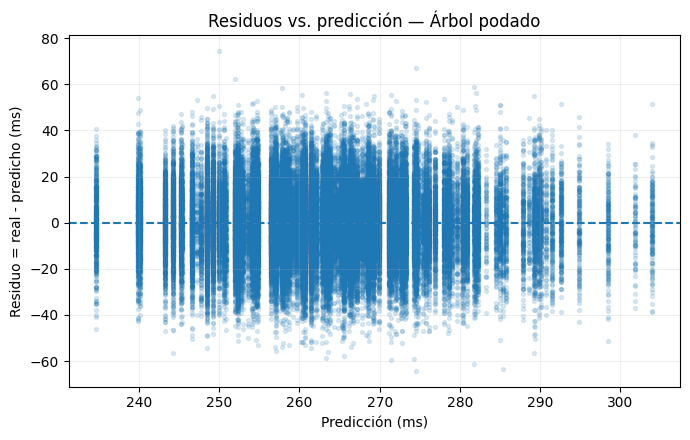

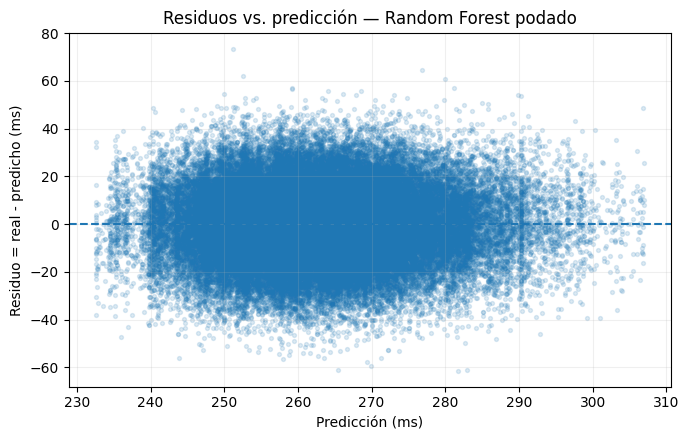

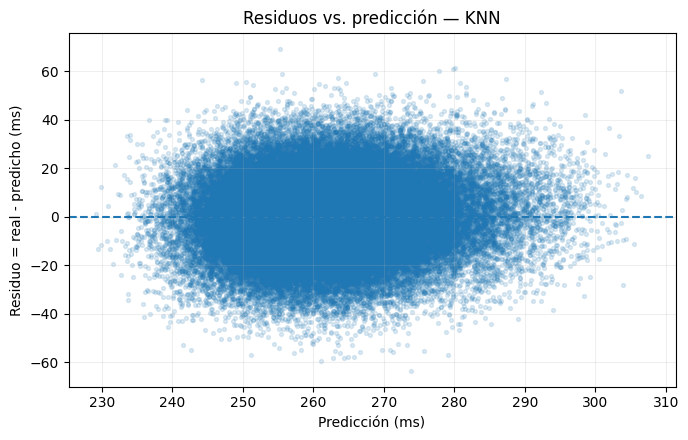

In [23]:
predictions = {
    'Árbol podado': pred_tree_pruned,
    'Random Forest podado': pred_rf_pruned,
    'KNN': pred_knn,
}

residual_rows = []
for name, pred in predictions.items():
    residuals = y_test.to_numpy() - pred
    residual_rows.append({
        'Modelo': name,
        'Residual_mean': residuals.mean(),
        'Residual_std': residuals.std(),
        'Residual_MAE': np.abs(residuals).mean(),
    })

residual_summary = pd.DataFrame(residual_rows)
display(residual_summary.round(4))

for name, pred in predictions.items():
    residuals = y_test.to_numpy() - pred
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(pred, residuals, s=8, alpha=.15)
    ax.axhline(0, linestyle='--')
    ax.set_xlabel('Predicción (ms)')
    ax.set_ylabel('Residuo = real - predicho (ms)')
    ax.set_title(f'Residuos vs. predicción — {name}')
    ax.grid(alpha=.2)
    plt.tight_layout()
    safe = name.lower().replace(' ', '_').replace('á','a').replace('ó','o')
    plt.savefig(RESULTS_DIR / f'fig_residuos_{safe}.png', dpi=140, bbox_inches='tight')
    plt.show()

## 7. Guía de lectura para el informe y la sustentación

1. **Diseño experimental:** primero se crea un Hold-Out 70/30. El 30% de TEST queda bloqueado. Toda selección se hace únicamente con TRAIN mediante Cross-Validation.
2. **Nodo raíz:** `feature_importances_` no decide la raíz. CART prueba splits y escoge la combinación variable+umbral que más reduce el error cuadrático. La tabla de atributos-raíz muestra el rendimiento individual de cada atributo como *stump* y la tabla por folds muestra qué raíz fue seleccionada realmente.
3. **Árbol de Decisión:** se comparan un árbol sin poda y un árbol regularizado. La estructura se selecciona con CV (`max_depth`, `min_samples_leaf`) y luego se aplica Cost-Complexity Pruning (`ccp_alpha`) con regla 1-SE.
4. **Random Forest:** cada árbol recibe una muestra bootstrap de TRAIN; no son bloques separados. La regularización se evalúa en los árboles del bosque y se comparan las versiones antes/después de poda.
5. **KNN:** `K` y `weights` se eligen con CV; TEST deja de participar en la elección. La figura final muestra vecinos, no clústeres.
6. **Comparación justa:** todos los modelos finales se evalúan con el mismo TEST y las mismas métricas MAE, RMSE y R². El baseline permite cuantificar cuánto mejora realmente cada algoritmo.
7. **Interpretación del R²:** el desempeño observado describe lo conseguido por estos datos y configuraciones; no debe presentarse como un “techo teórico” del fenómeno.
8. **Informe:** las tablas CSV y figuras PNG quedan automáticamente guardadas en `resultados_regresion/`, listas para citar o insertar en el documento.